In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score,r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:

df = pd.read_csv(r"C:\Users\dines\OneDrive\Desktop\Battery Health & Remaining Life\battery_rul_dataset.csv ", engine="python", encoding="latin1", on_bad_lines="skip")


In [13]:
print(df.isnull().sum())
print(df.shape)
print(df.describe())
print(df.info())
print(df.columns)


Cycle_Index                  0
Discharge Time (s)           0
Decrement 3.6-3.4V (s)       0
Max. Voltage Dischar. (V)    0
Min. Voltage Charg. (V)      0
Time at 4.15V (s)            0
Time constant current (s)    0
Charging time (s)            0
RUL                          0
dtype: int64
(15064, 9)
        Cycle_Index  Discharge Time (s)  Decrement 3.6-3.4V (s)  \
count  15064.000000        15064.000000            15064.000000   
mean     556.155005         4581.273960             1239.784672   
std      322.378480        33144.012077            15039.589269   
min        1.000000            8.690000          -397645.908000   
25%      271.000000         1169.310000              319.600000   
50%      560.000000         1557.250000              439.239471   
75%      833.000000         1908.000000              600.000000   
max     1134.000000       958320.370000           406703.768000   

       Max. Voltage Dischar. (V)  Min. Voltage Charg. (V)  Time at 4.15V (s)  \
count        

In [14]:
X=df.drop(columns=['RUL'])
y=df['RUL']

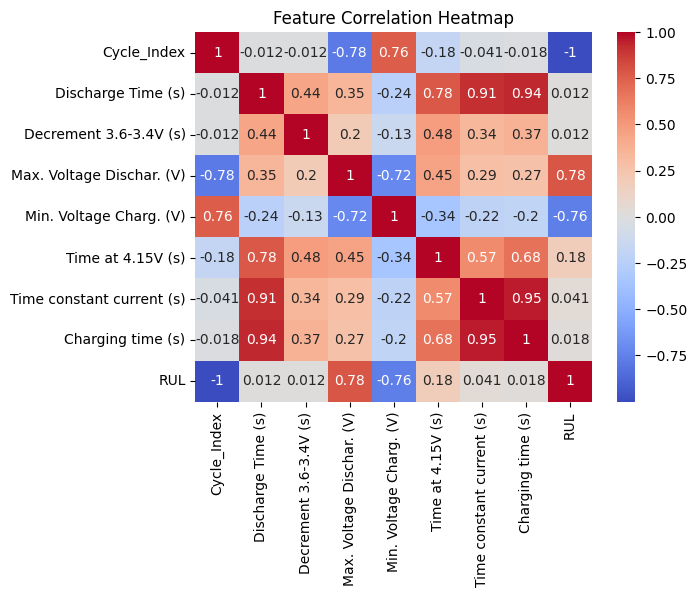

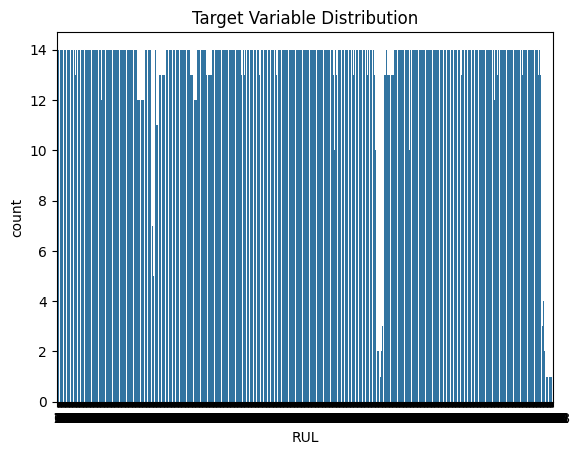

In [15]:
plt.Figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()
sns.countplot(x=y)
plt.title('Target Variable Distribution')
plt.show()

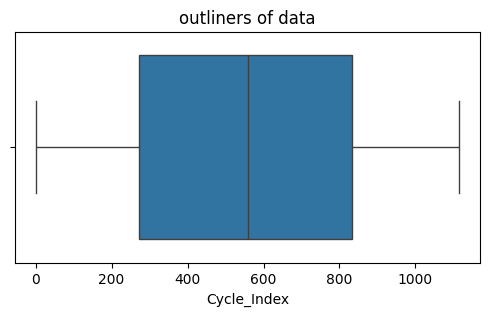

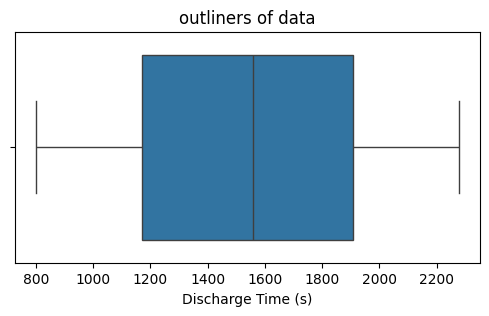

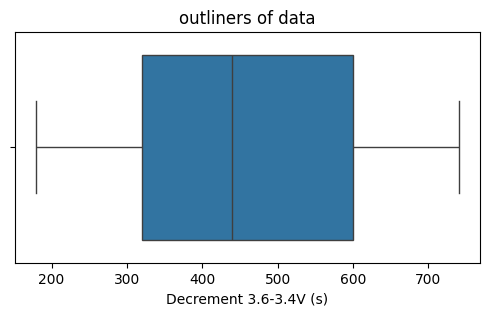

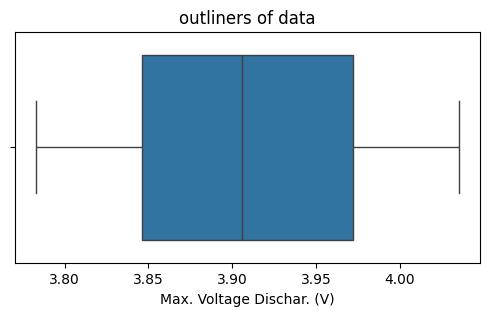

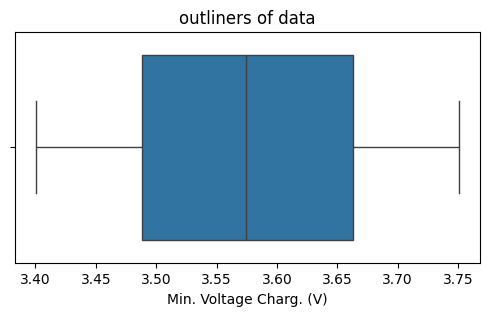

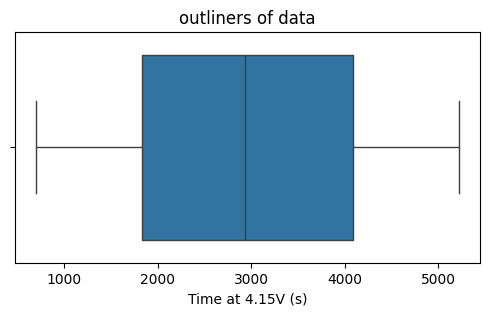

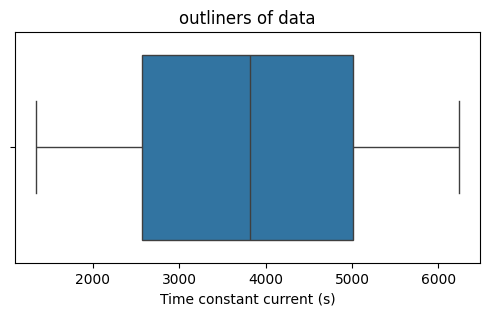

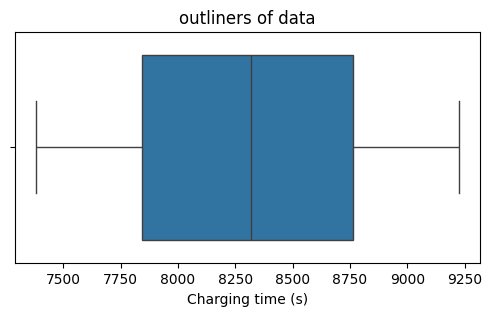

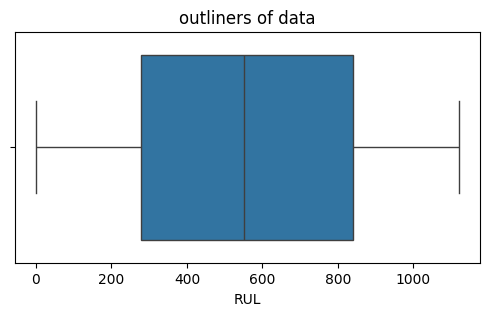

In [ ]:
for i in df.select_dtypes(include='number').columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[i])
    plt.title('outliners of data')
    plt.show()
for k in df.select_dtypes(include='number').columns:
    q1=df[k].quantile(0.25)
    q3=df[k].quantile(0.75)
    IQR=q3-q1
    lower_limit=q1-1.5*IQR
    upper_limit=q3+1.5*IQR
    df[k]=np.where(df[k]<lower_limit,lower_limit,
                   np.where(df[k]>upper_limit,upper_limit,df[k]))

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
models={
    'logistic':LogisticRegression(max_iter=1000),
    'gardient':GradientBoostingRegressor(
          n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    loss='huber',       # Options: 'squared_error', 'absolute_error', 'huber', 'quantile'
    random_state=42
    ),   
    'decision':DecisionTreeRegressor(
        criterion='gini',
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
    )
}
result={}
for name ,model in models.items():
    model.fit(X_train,y_train)
    y_predict=model.predict(X_test)
    score=r2_score(y_predict,y_test)
    result[name]=score
for name,score in result.items():
    print(f"{name} : {score:.4f}")

In [ ]:
cm=confusion_matrix(y_predict,y_test)
display=ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot(cmap='Blues')
plt.title('confusion_matrix')
plt.show()

In [ ]:
mse=mean_squared_error(y_predict,y_test)
rmse=np.sqrt(mean_squared_error(y_predict,y_test))
mae=mean_absolute_error(y_predict,y_test)

In [ ]:
gradient=model['gradent']
